In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as cst

from scipy import optimize
from tqdm import tqdm

## The Euler equations

The behaviour of an ideal compressible gas is described by the Euler equations:

$$ \frac{\partial \rho}{\partial t} + \nabla \cdot \rho\,\vec{u} = 0 $$
$$ \frac{\partial (\rho \vec{u})}{\partial t} + \nabla \cdot (\rho\,\vec{u}^2 + p) = 0 $$
$$ \frac{\partial e}{\partial t} + \nabla \cdot (e+p) \,\vec{u} = 0 $$

with the total energy of the gas being:

$$ e = e_\mathrm{int} + \frac{1}{2} \rho\,\vec{u}^2 = \frac{p}{\gamma-1} + \frac{1}{2} \rho\,\vec{u}^2 $$

where $\gamma = 5/3$ for a monatomic gas and the gas pressure

$$ p = \frac{\rho\,k_B\,T}{\mu\,m_\mathrm{H}} $$

with $\mu$ the mean molecular weight.

A more general form of the Euler equations is (and here for the 1D case):

$$ \frac{\partial \mathbf{W}}{\partial t} + \frac{\partial \mathbf{F}}{\partial x} = 0 $$

here the $\mathbf{W}$ is the state vector and $\mathbf{F}$ the flux vector, defined as:

$$ W(\rho, \vec{u}, p) = 
    \begin{pmatrix}
        \rho \\
        \rho\,\vec{u} \\
        e
    \end{pmatrix}
$$

and

$$ F(\rho, \vec{u}, p) = 
    \begin{pmatrix}
        \rho\,\vec{u} \\
        \rho\,\vec{u}^2+p \\
        (e+p)\,\vec{u}
    \end{pmatrix}
$$

In [3]:
# Convert to primitive variables
def get_primitive(W):
    rho = W[:,0]
    v = W[:,1] / rho
    E = W[:,2]
    
    #TODO: this one is for higher dimension
    #P = (gamma - 1)*(E - 0.5*rho*np.linalg.norm(v))
    
    P = (gamma - 1)*(E - 0.5*rho*v**2)
    return rho, v, P, E

def plot_state(x_grid, U):
    
    # get primitive quantities
    rho, vel, pres, energ = get_primitive(U)
    
    # create figure
    fig, axs = plt.subplots(figsize=(12,4), ncols=3, nrows=1, sharex=True)
    
    # plot density
    axs[0].plot(x_grid, rho)
    axs[0].set_ylabel(r"$\rho$")

    # plot velocity
    axs[1].plot(x_grid, vel)
    axs[1].set_ylabel(r"$|u|$")

    # plot pressure
    plt.subplot(1,3,3)
    axs[2].plot(x_grid, pres)
    axs[2].set_ylabel("P")

    for ax in axs.flatten():
        ax.set_xlabel("x")
        
    plt.tight_layout()
    
    return axs

In [4]:
def roe_fluxes(U, gamma, eps_entropy=0.1):
    """
    Compute Roe fluxes at interfaces for 1D Euler.
    Inputs:
      U : arrays of cell-centered conserved variables (length N)
      gamma : ratio of specific heats
      eps_entropy : entropy-fix parameter fraction (0.1 typical)
    Returns:
      flux_iface : array shape (N+1, 3) of interface fluxes F_{i+1/2}
    Notes:
      - No reconstruction (first-order in space).
      - Uses Roe linearization and eigen-decomposition per interface.
    """
    N = U.shape[0]
    
    # primitives quantities
    rho,u, p, ener = get_primitive(U)
    h = (ener + p) / rho

    # left/right states at interfaces i+1/2
    rhoL = rho[:-1]
    rhoR = rho[1:]
    uL = u[:-1]; uR = u[1:]
    hL = h[:-1]; hR = h[1:]
    pL = p[:-1]; pR = p[1:]
    EL = ener[:-1]; ER = ener[1:]

    # Roe averages (weighted by sqrt(rho))
    sqL = np.sqrt(rhoL)
    sqR = np.sqrt(rhoR)
    u_tilde = (sqL*uL + sqR*uR) / (sqL + sqR)
    h_tilde = (sqL*hL + sqR*hR) / (sqL + sqR)

    # Roe-averaged sound speed
    a_tilde = (gamma - 1.0) * (h_tilde - 0.5 * u_tilde**2)
    
    # avoid small negative due to roundoff
    a_tilde = np.sqrt(np.where(a_tilde > 0.0, a_tilde, np.abs(a_tilde)))

    # eigenvalues (wave speeds)
    lam = np.vstack((u_tilde - a_tilde, u_tilde, u_tilde + a_tilde)).T   # shape (N-1,3)
    abs_lam = np.abs(lam)

    # Roe’s solver can violate the entropy condition (creating unphysical expansion shocks) -> entropy fix (Harten-Hyman style)
    delta = eps_entropy * a_tilde
    small_mask = abs_lam < delta[:,None]
    abs_lam = np.where(small_mask, 0.5*(lam**2/delta[:,None] + delta[:,None]), abs_lam)

    # left and right fluxes
    FL = np.column_stack((rhoL*uL,
                          rhoL*uL**2 + pL,
                          uL*(EL + pL)))
    FR = np.column_stack((rhoR*uR,
                          rhoR*uR**2 + pR,
                          uR*(ER + pR)))

    # state difference ΔU = U_R - U_L
    dU = np.column_stack((rhoR - rhoL,
                          rhoR*uR - rhoL*uL,
                          ER - EL))   # shape (N-1,3)

    # allocate fluxes
    F_iface = np.zeros((N+1, 3))

    # loop over interfaces (N-1 interfaces)
    for i in range(N-1):
        # Roe eigenvectors (columns)
        r1 = np.array([1.0, u_tilde[i] - a_tilde[i], h_tilde[i] - u_tilde[i]*a_tilde[i]])
        r2 = np.array([1.0, u_tilde[i], 0.5*u_tilde[i]**2])
        r3 = np.array([1.0, u_tilde[i] + a_tilde[i], h_tilde[i] + u_tilde[i]*a_tilde[i]])
        R = np.column_stack((r1, r2, r3))   # 3x3

        # solve for alpha: R * alpha = dU
        # guard small/ill-conditioned by using solve; it's robust for 3x3
        alpha = np.linalg.solve(R, dU[i, :])

        # This term represents the numerical viscosity added to stabilize the scheme (dissipative term)
        diss = abs_lam[i,0]*alpha[0]*r1 + abs_lam[i,1]*alpha[1]*r2 + abs_lam[i,2]*alpha[2]*r3

        # Roe flux
        F_iface[i+1] = 0.5*(FL[i] + FR[i]) - 0.5 * diss

    # simple boundary treatment: Here we set the leftmost and rightmost interface fluxs as the cell-centered flux (user can replace with proper boundary conditions)
    F_iface[0] = FL[0]
    F_iface[-1] = FR[-1]

    return F_iface


# TODO: not working
def hllc_flux(U):
    F = np.zeros_like(U)
    
    for i in range(1, U.shape[0]):
        UL, UR = U[i-1], U[i]
        
        # Left and right states
        rhoL, uL, EL = UL
        rhoR, uR, ER = UR
        pL = (gamma-1)*(EL - 0.5*rhoL*uL**2)
        pR = (gamma-1)*(ER - 0.5*rhoR*uR**2)

        # sound speeds
        aL = np.sqrt(gamma*pL/rhoL)
        aR = np.sqrt(gamma*pR/rhoR)

        # estimate wave speeds (Davis 1988)
        SL = min(uL - aL, uR - aR)
        SR = max(uL + aL, uR + aR)

        # fluxes
        FL = np.array([rhoL*uL, rhoL*uL**2 + pL, uL*(EL+pL)])
        FR = np.array([rhoR*uR, rhoR*uR**2 + pR, uR*(ER+pR)])

        if SL >= 0:
            F[i] = FL
        elif SR <= 0:
            return FR
        else:
            S_star = (pR - pL + rhoL*uL*(SL - uL) - rhoR*uR*(SR - uR)) / (rhoL*(SL - uL) - rhoR*(SR - uR))
            U_starL = rhoL*(SL - uL)/(SL - S_star) * np.array([1, S_star, EL/rhoL + (S_star-uL)*(S_star + pL/(rhoL*(SL-uL)))])
            U_starR = rhoR*(SR - uR)/(SR - S_star) * np.array([1, S_star, ER/rhoR + (S_star-uR)*(S_star + pR/(rhoR*(SR-uR)))])
            if S_star >= 0:
                F[i] = FL + SL*(U_starL - UL)
            else:
                F[i] = FR + SR*(U_starR - UR)

    return F


Consider a uniform 1D grid, dicretised in the domain $[x_L, x_R]$ and with physical size $\Delta x$. The position of each grid element is as follows: 

$$x_i = x_L+(i+1/2)\Delta x$$

We will also define the position of the boundary need the midpoint values:

$$x_{i-1/2} = x_i - \Delta x = x_L+i \Delta x$$

These values define computational cells: $C_i = [x_{i-1/2},x_{i+1/2}]$

Any quantity $U$ of the cell at position $x_i$ and time $t_n$ are defined numerically as:

$$U(x_i, t_n) = \frac{1}{\Delta x}\int_{x_{i-1/2}}^{x_{i+1/2}}U(x,t_n)\, dx$$

In [5]:
Nx = 128
x0, x1 = 0.0, 1.0
dx = (x1 - x0)/Nx

x = x0+(np.arange(Nx)+1/2)*dx

gamma = 1.4
t_start = 0
t_end = 0.2

In [6]:
# conserved variables: [rho, rho*u, E]
U = np.zeros((Nx, 3))

# left and right states (Sod shock tube inital conditions)
rho_left, u_left, p_left = 1.0, 0.0, 1.0
rho_right, u_right, p_right = 0.125, 0.0, 0.1

# Sod shock tube initial state conditions
mid = Nx // 2
U[:mid,0] = rho_left
U[:mid,1] = rho_left * u_left
U[:mid,2] = p_left/(gamma-1) + 0.5 * rho_left * u_left**2

U[mid:,0] = rho_right
U[mid:,1] = rho_right*u_right
U[mid:,2] = p_right/(gamma-1) + 0.5 * rho_right * u_right**2

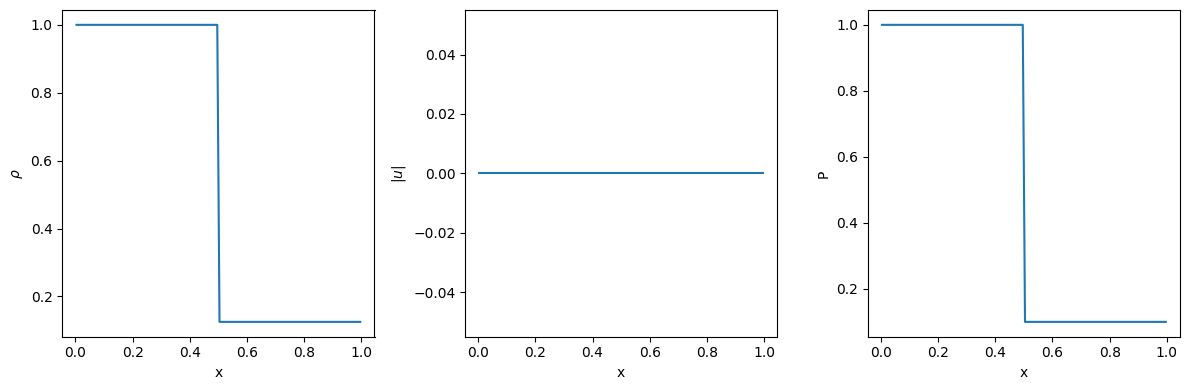

(None, None)

<Figure size 640x480 with 0 Axes>

In [8]:
# plot initial condition of the Sod test
axs = plot_state(x_grid=x, U=U)
plt.show(), plt.clf()

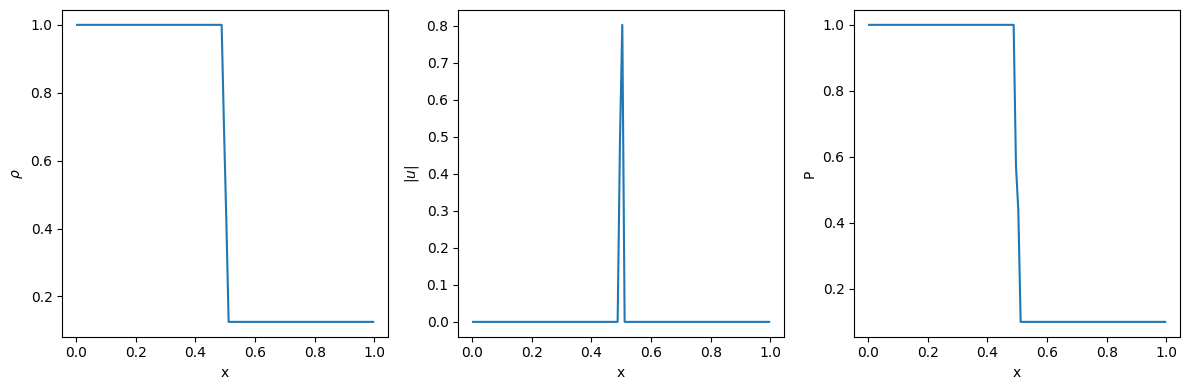

<Figure size 640x480 with 0 Axes>

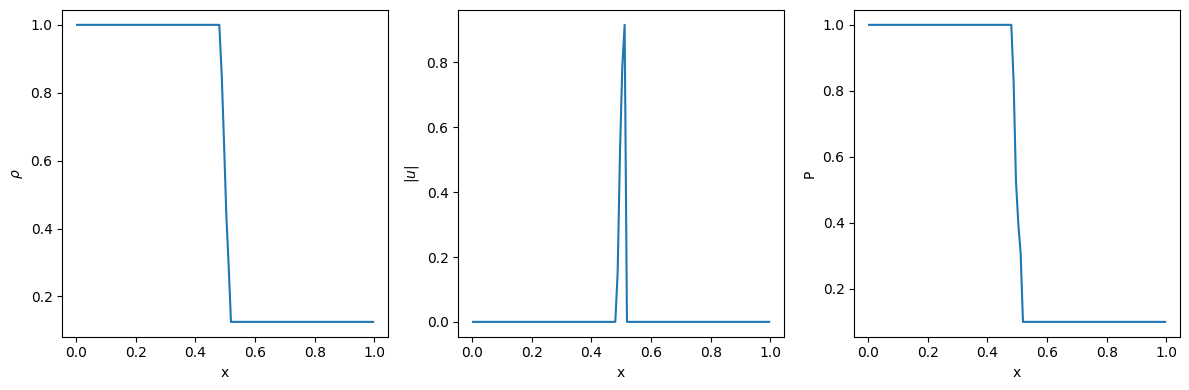

<Figure size 640x480 with 0 Axes>

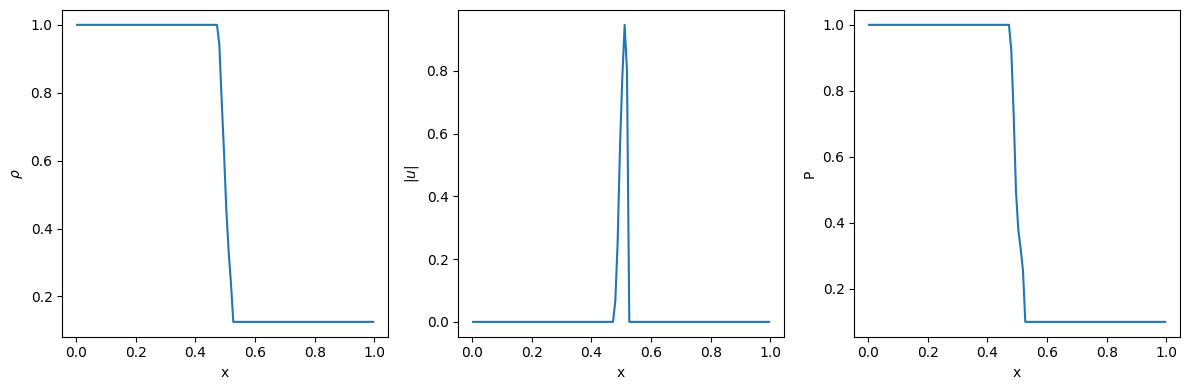

<Figure size 640x480 with 0 Axes>

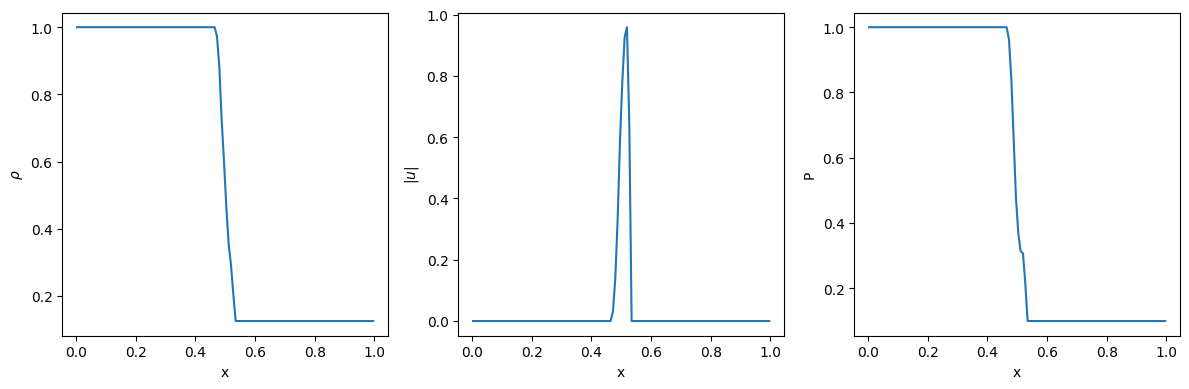

<Figure size 640x480 with 0 Axes>

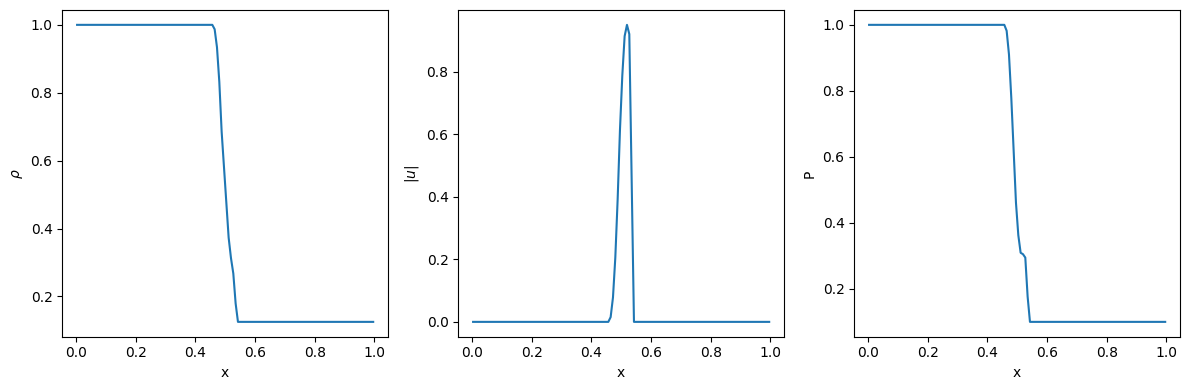

<Figure size 640x480 with 0 Axes>

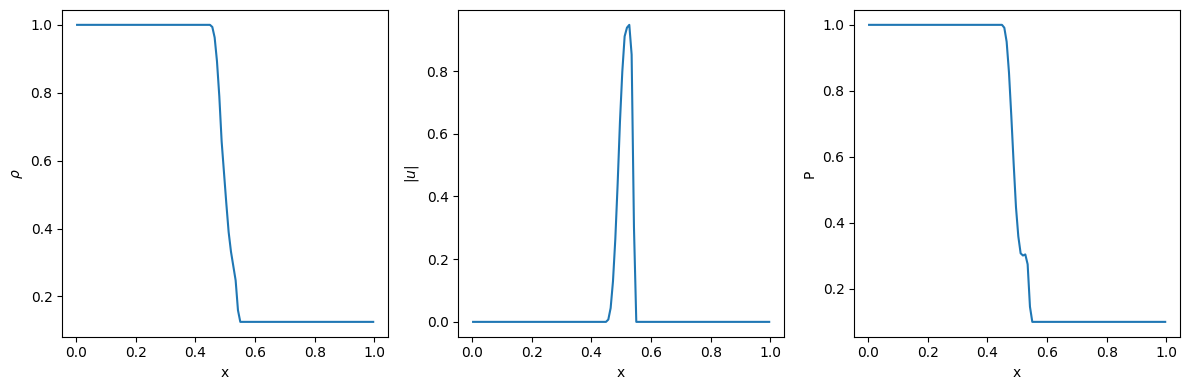

<Figure size 640x480 with 0 Axes>

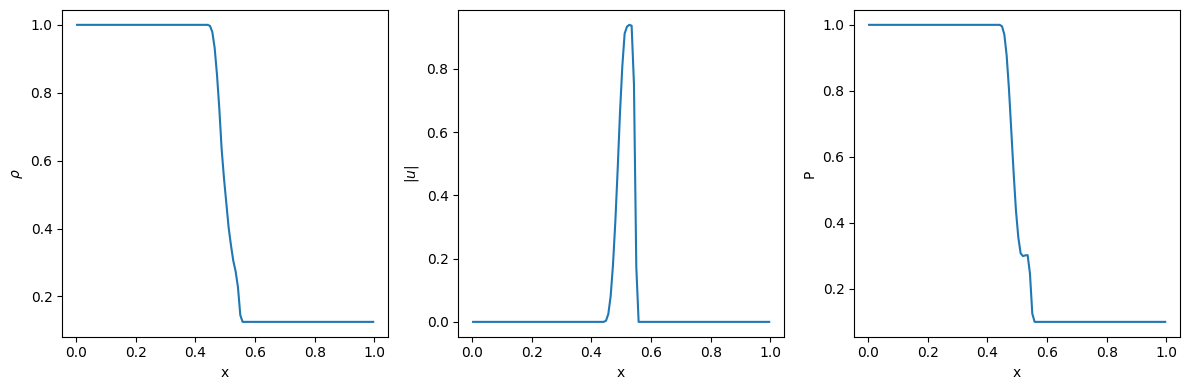

<Figure size 640x480 with 0 Axes>

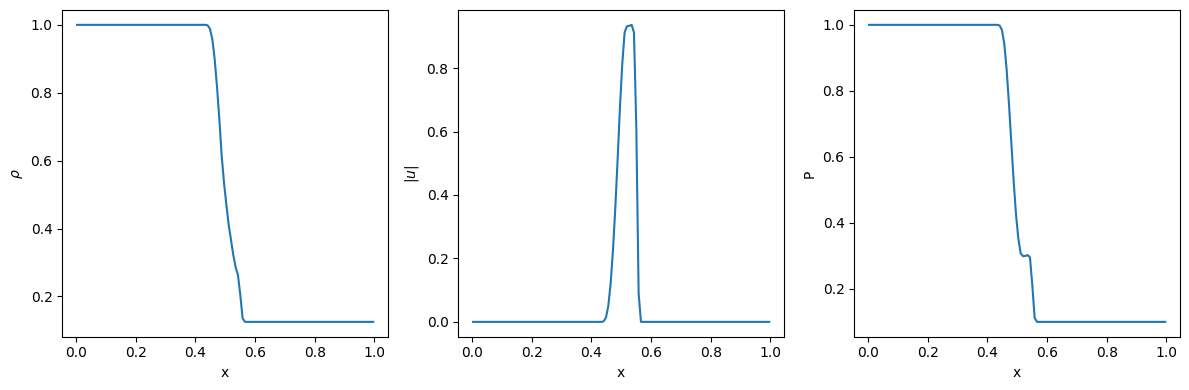

<Figure size 640x480 with 0 Axes>

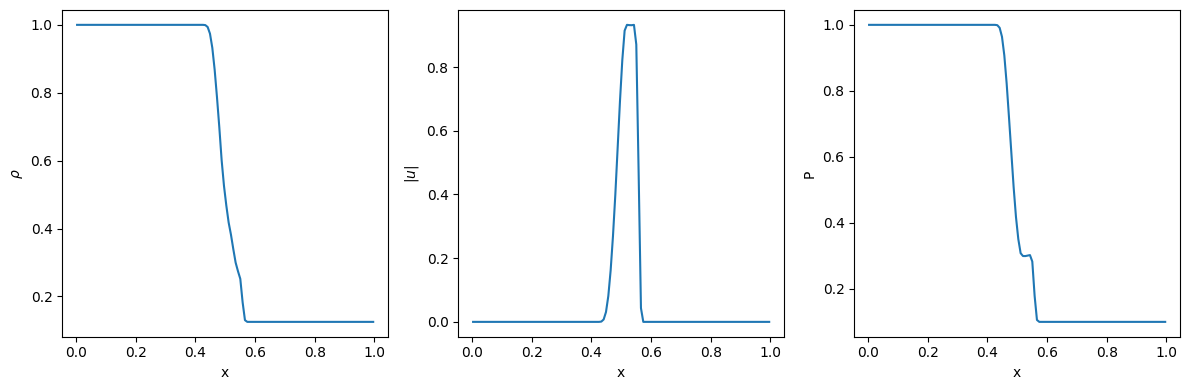

<Figure size 640x480 with 0 Axes>

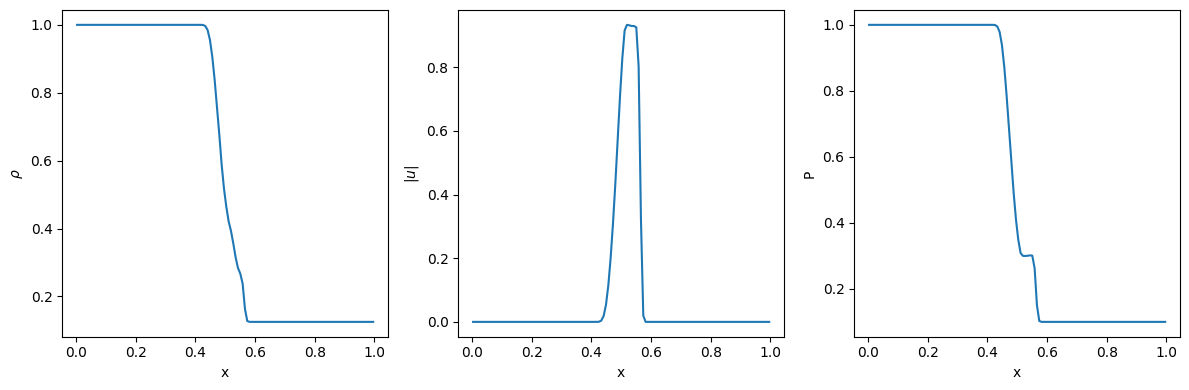

<Figure size 640x480 with 0 Axes>

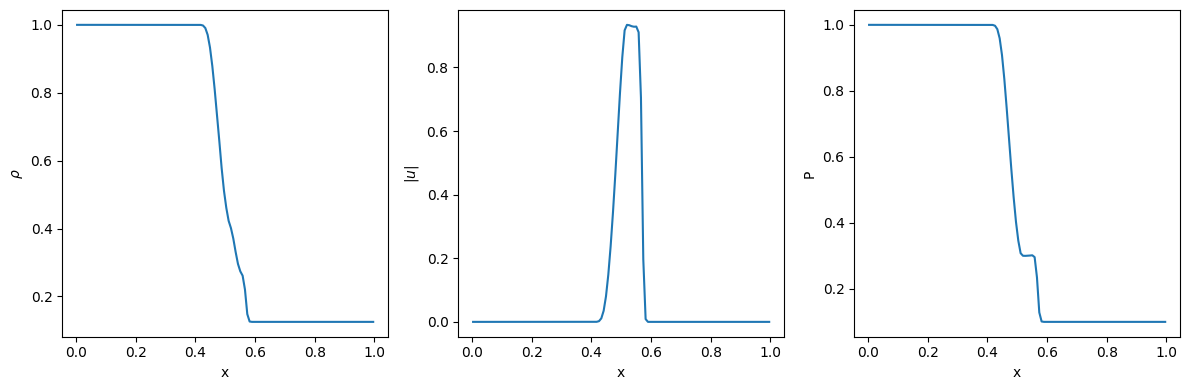

<Figure size 640x480 with 0 Axes>

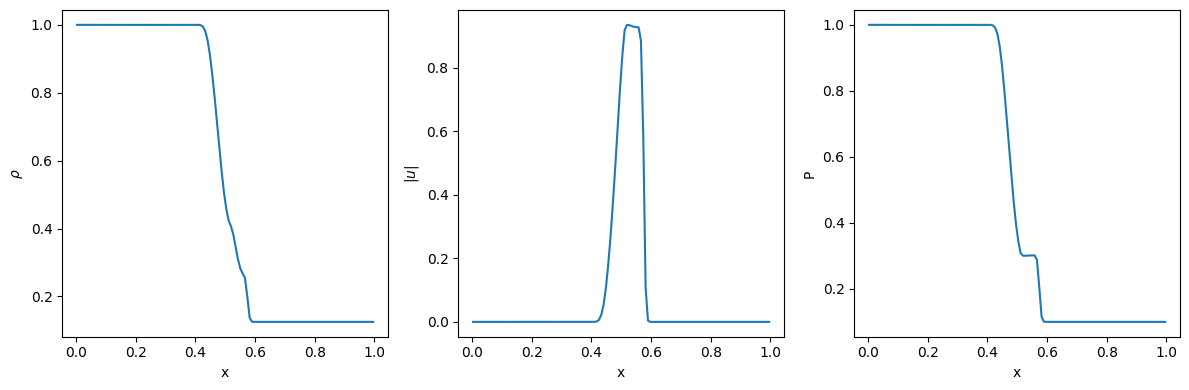

<Figure size 640x480 with 0 Axes>

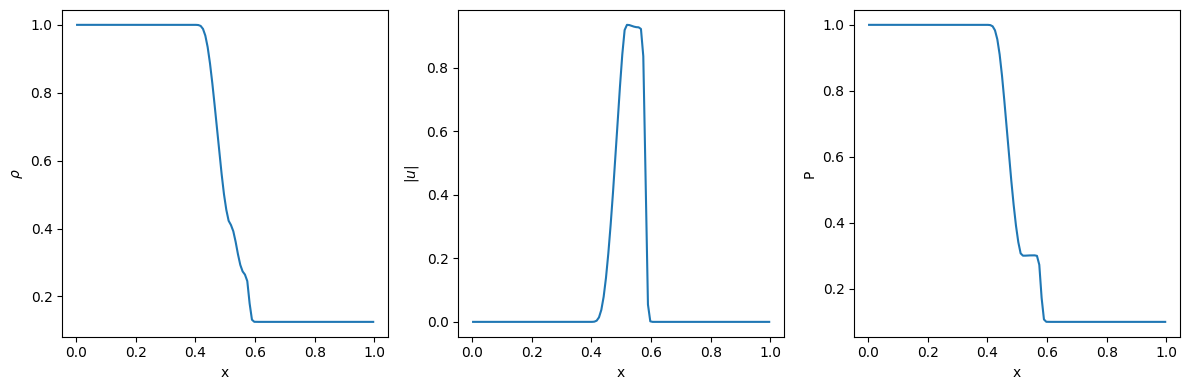

<Figure size 640x480 with 0 Axes>

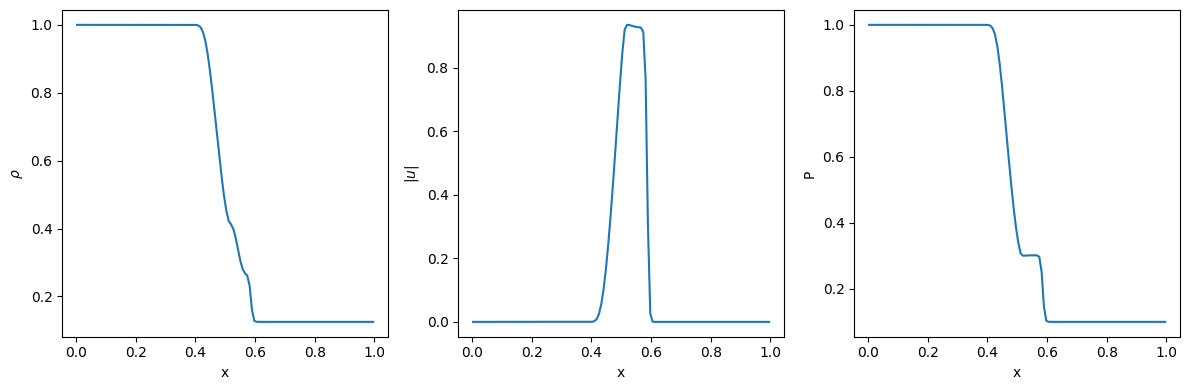

<Figure size 640x480 with 0 Axes>

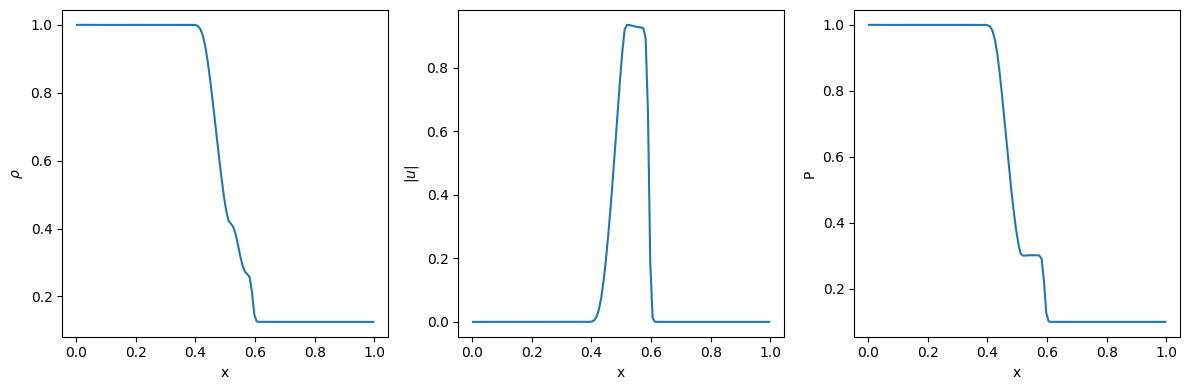

<Figure size 640x480 with 0 Axes>

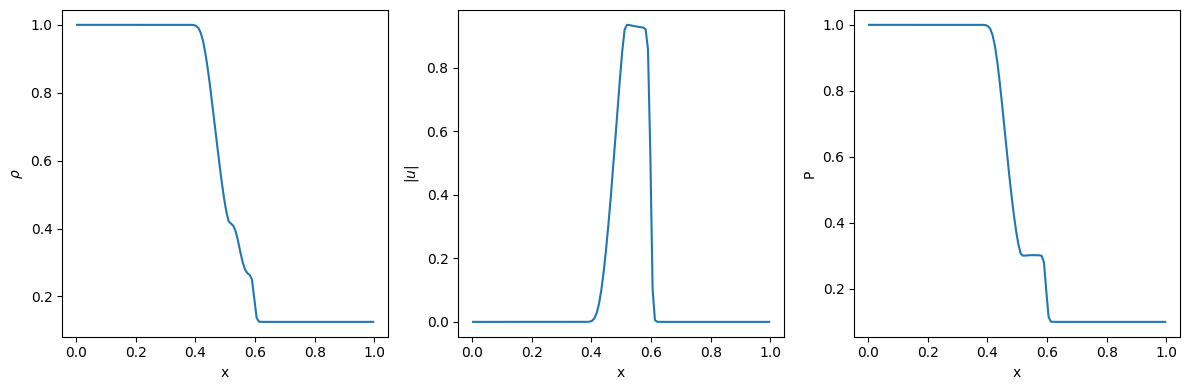

<Figure size 640x480 with 0 Axes>

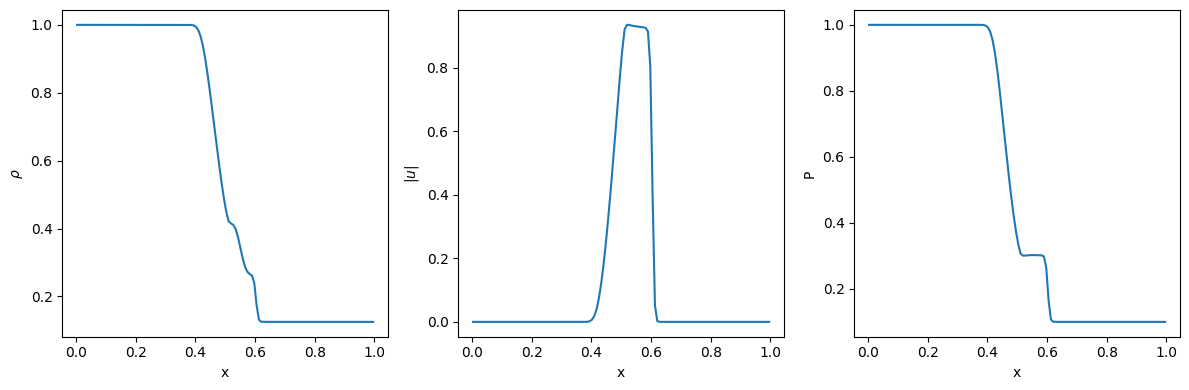

<Figure size 640x480 with 0 Axes>

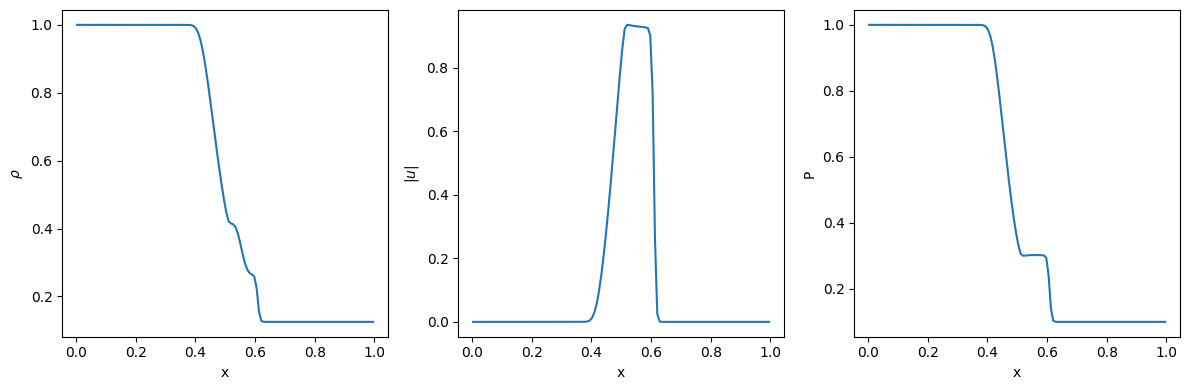

<Figure size 640x480 with 0 Axes>

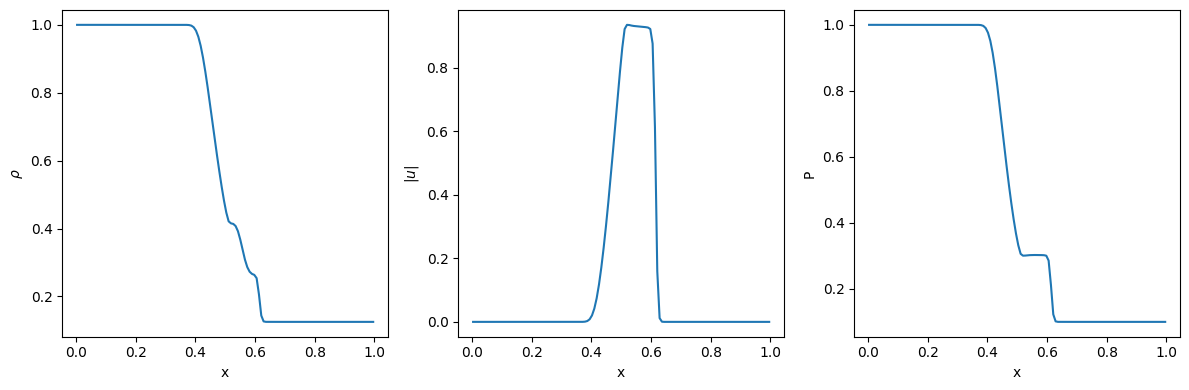

<Figure size 640x480 with 0 Axes>

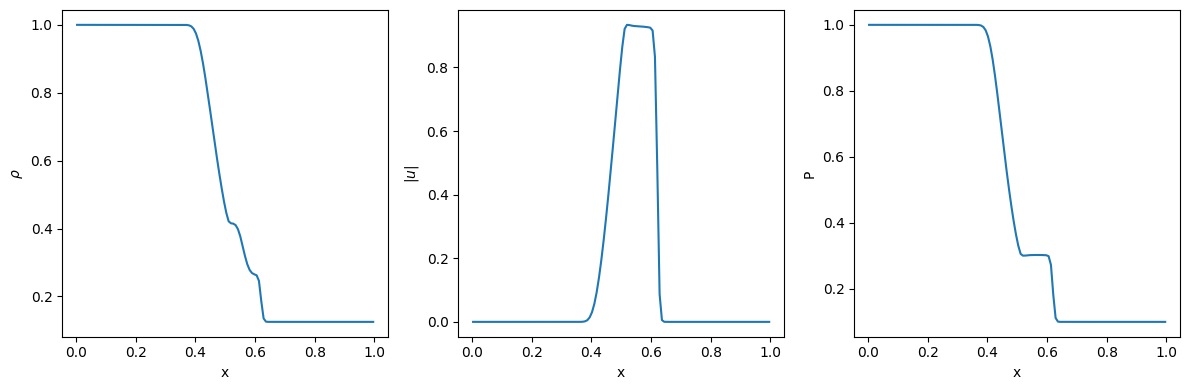

<Figure size 640x480 with 0 Axes>

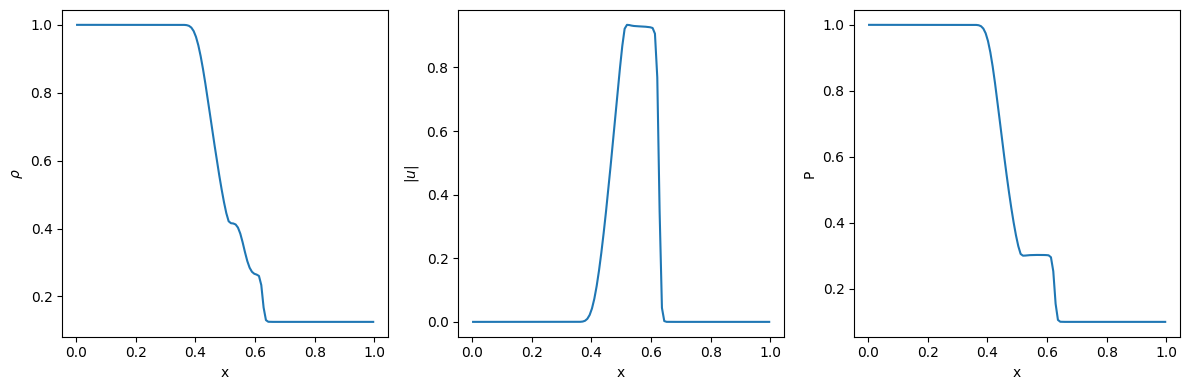

<Figure size 640x480 with 0 Axes>

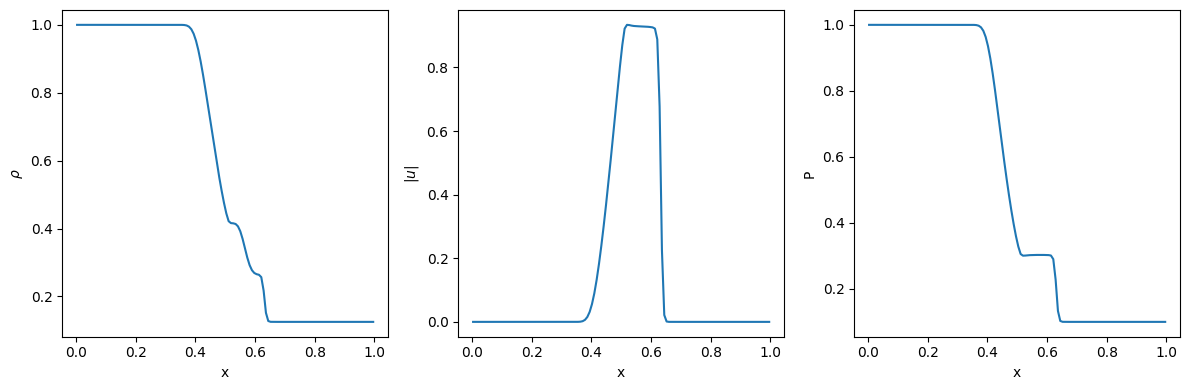

<Figure size 640x480 with 0 Axes>

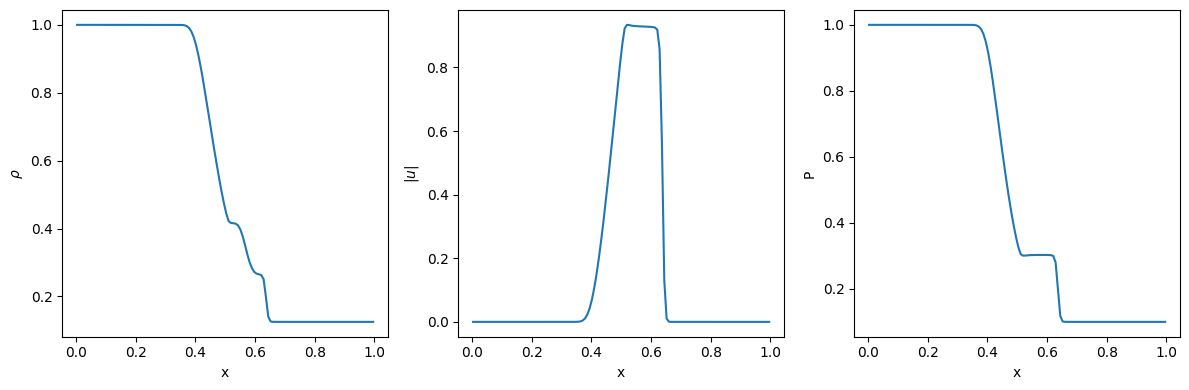

<Figure size 640x480 with 0 Axes>

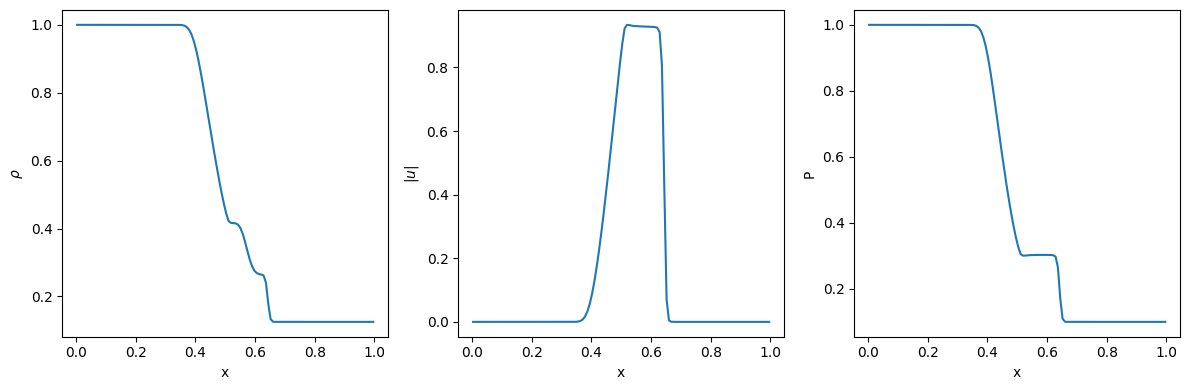

<Figure size 640x480 with 0 Axes>

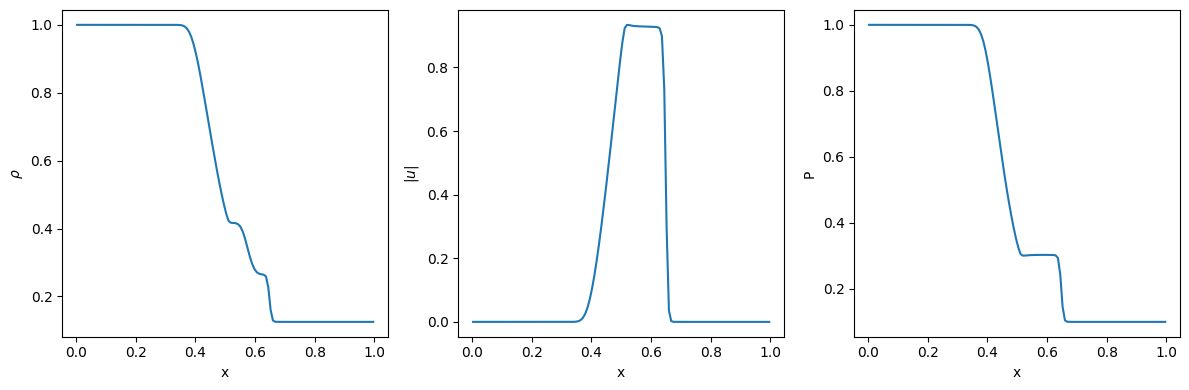

<Figure size 640x480 with 0 Axes>

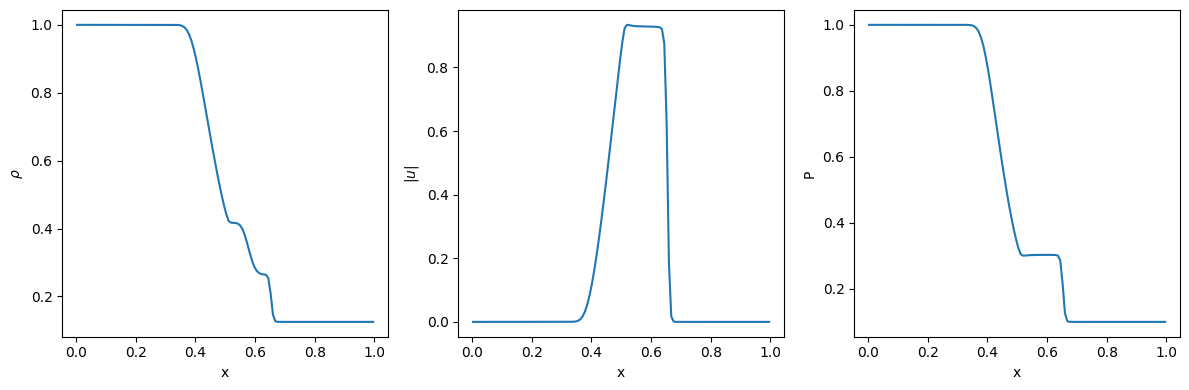

<Figure size 640x480 with 0 Axes>

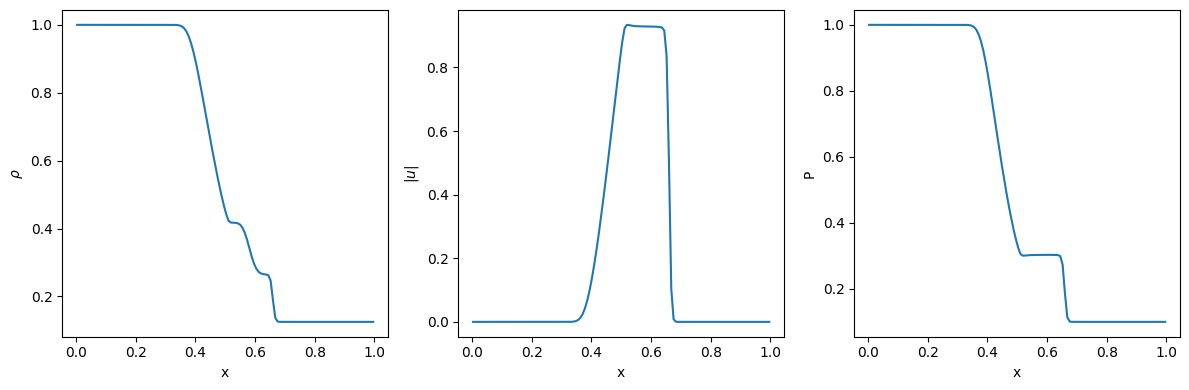

<Figure size 640x480 with 0 Axes>

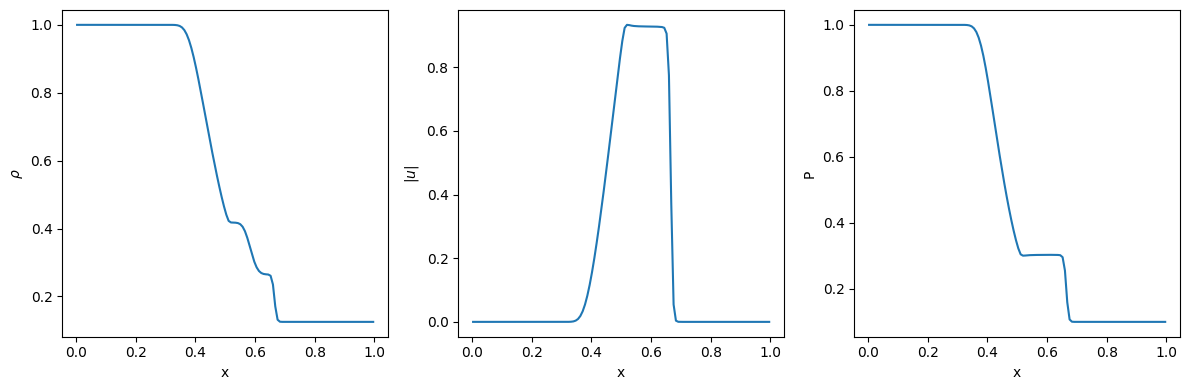

<Figure size 640x480 with 0 Axes>

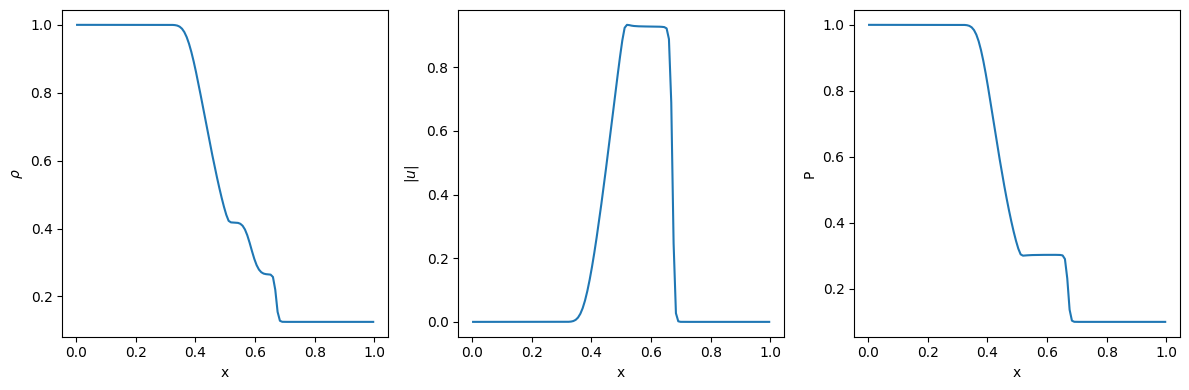

<Figure size 640x480 with 0 Axes>

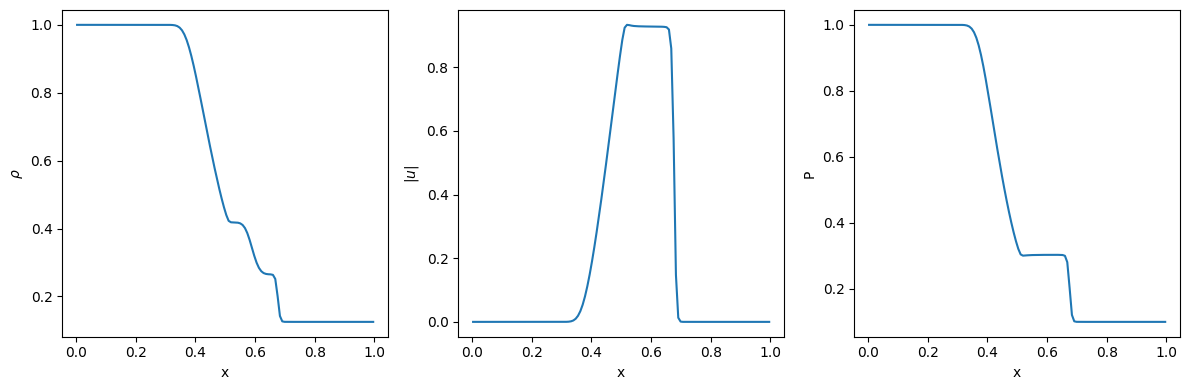

<Figure size 640x480 with 0 Axes>

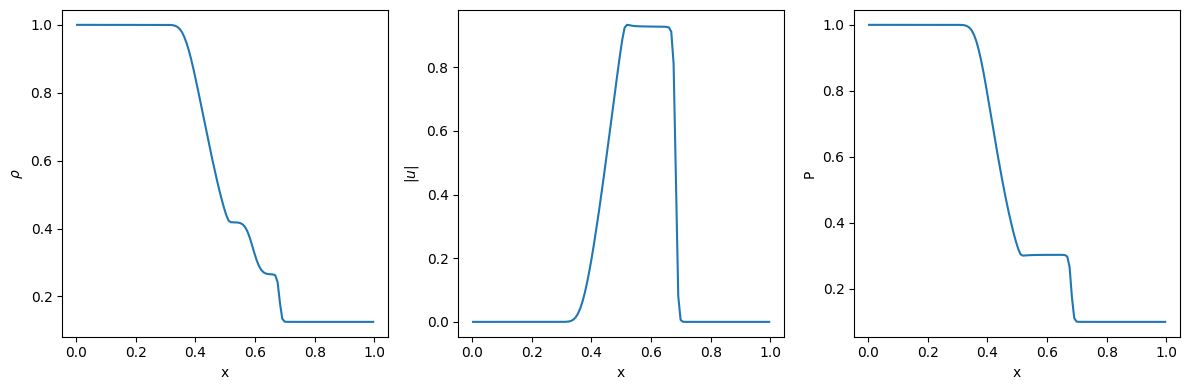

<Figure size 640x480 with 0 Axes>

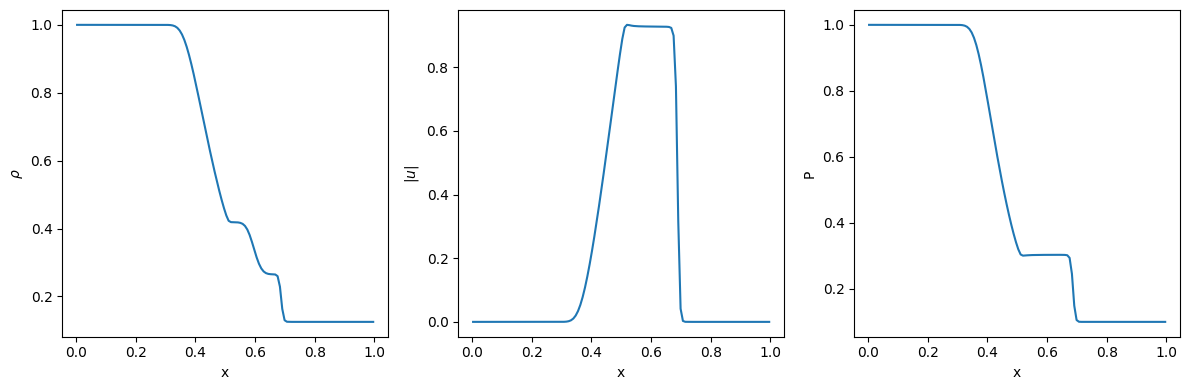

<Figure size 640x480 with 0 Axes>

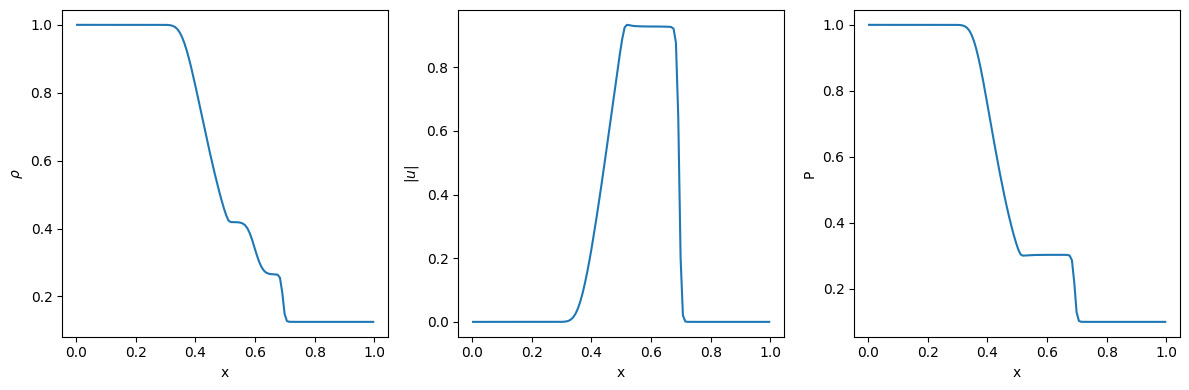

<Figure size 640x480 with 0 Axes>

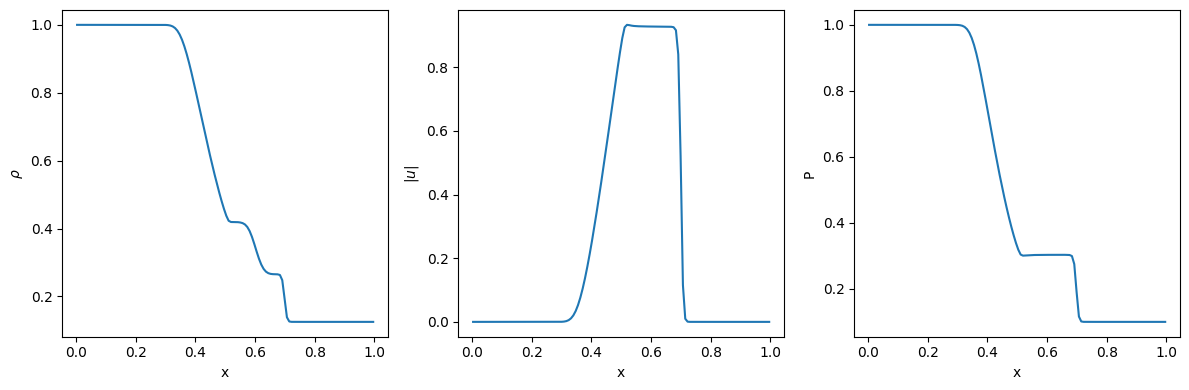

<Figure size 640x480 with 0 Axes>

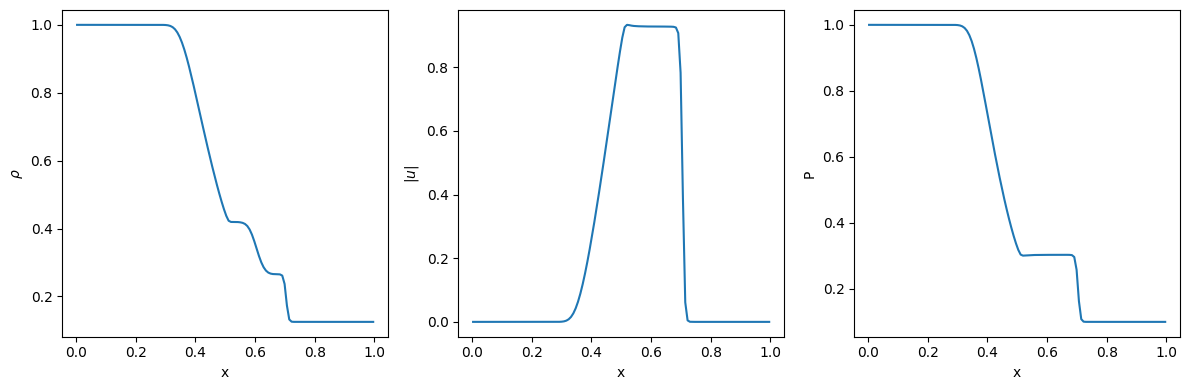

<Figure size 640x480 with 0 Axes>

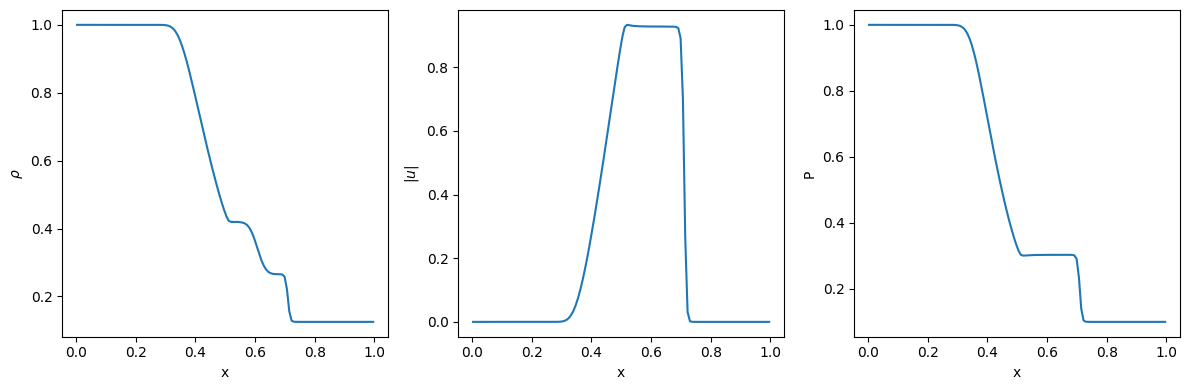

<Figure size 640x480 with 0 Axes>

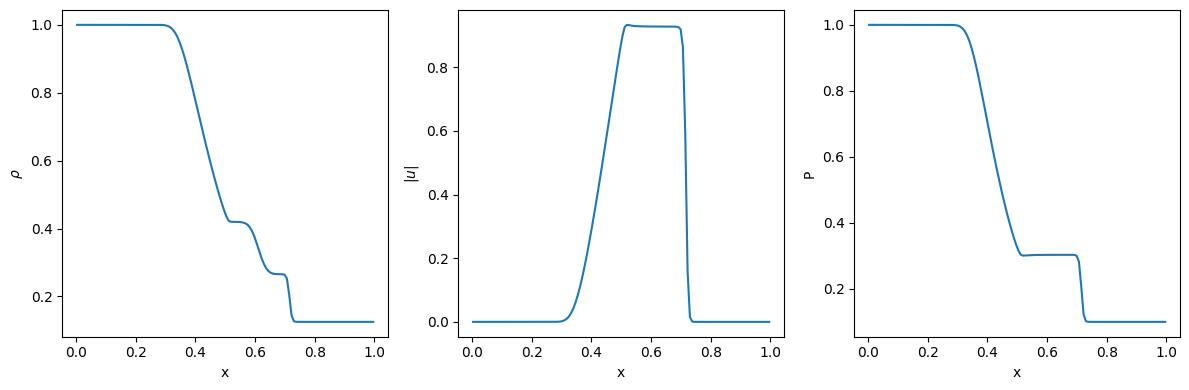

<Figure size 640x480 with 0 Axes>

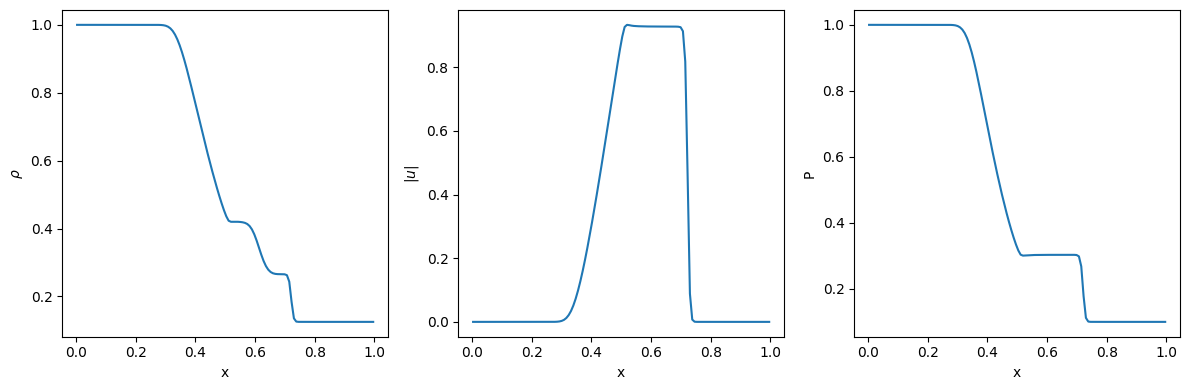

<Figure size 640x480 with 0 Axes>

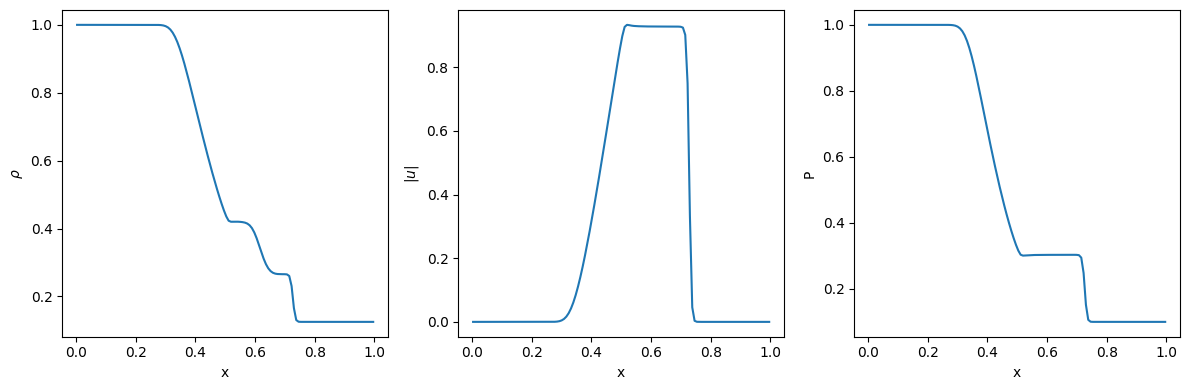

<Figure size 640x480 with 0 Axes>

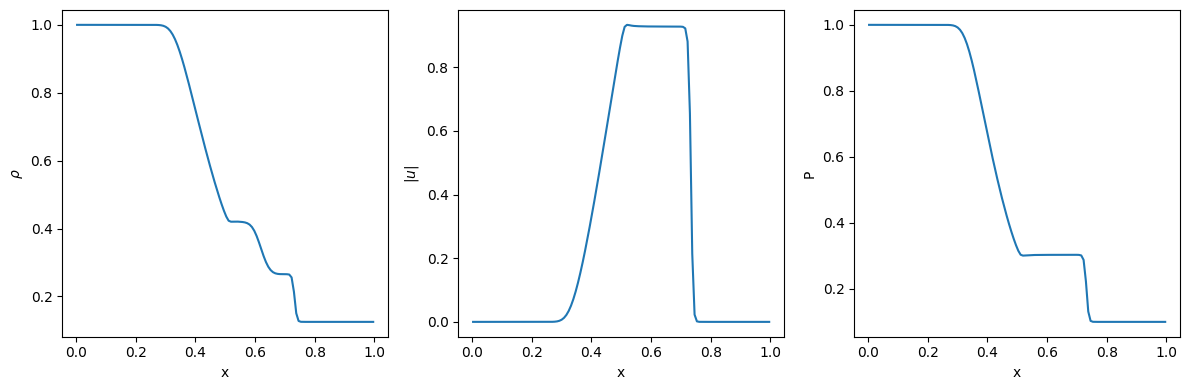

<Figure size 640x480 with 0 Axes>

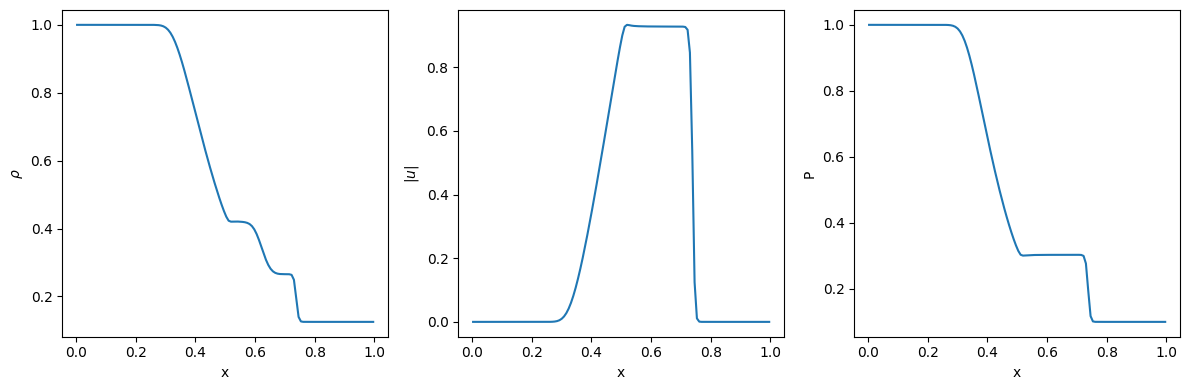

<Figure size 640x480 with 0 Axes>

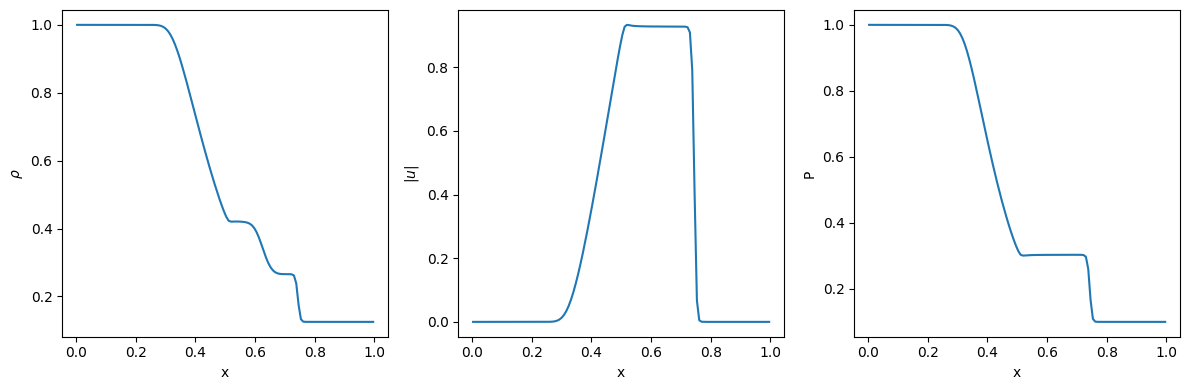

<Figure size 640x480 with 0 Axes>

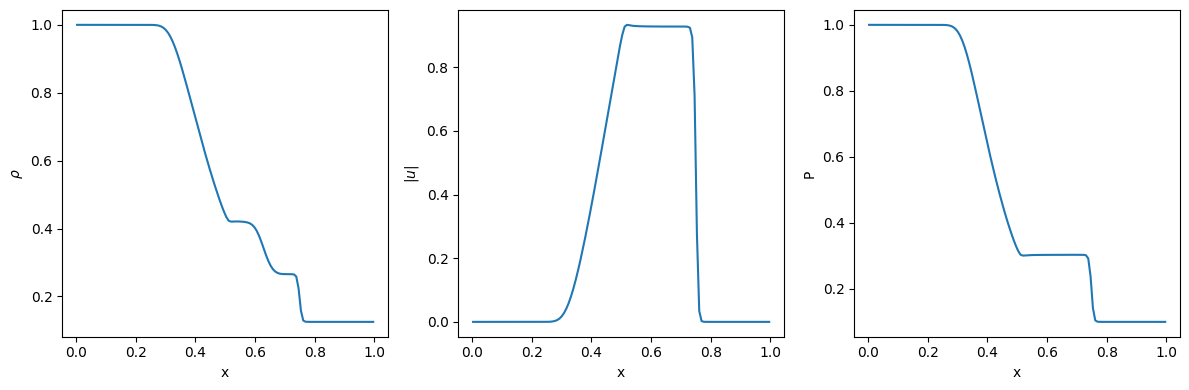

<Figure size 640x480 with 0 Axes>

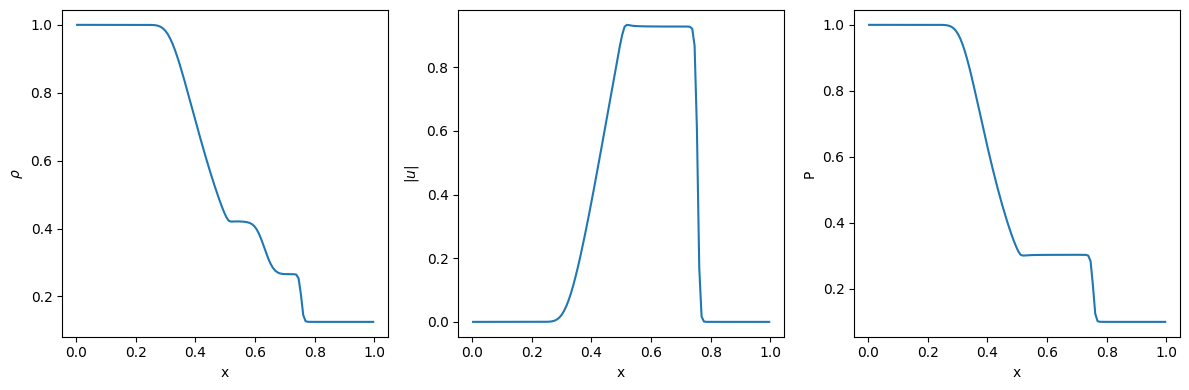

<Figure size 640x480 with 0 Axes>

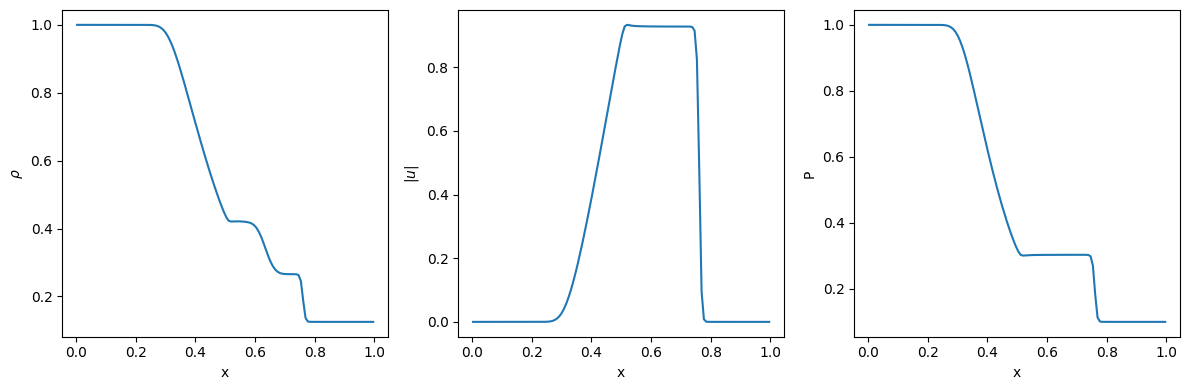

<Figure size 640x480 with 0 Axes>

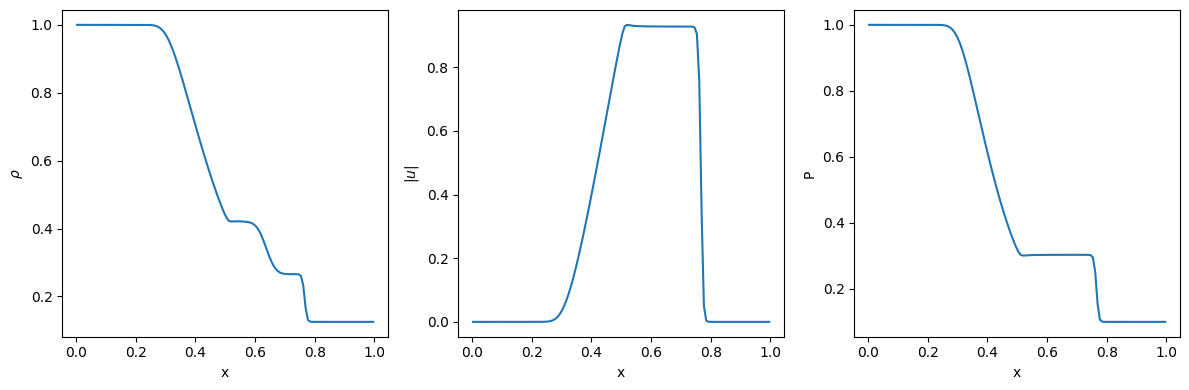

<Figure size 640x480 with 0 Axes>

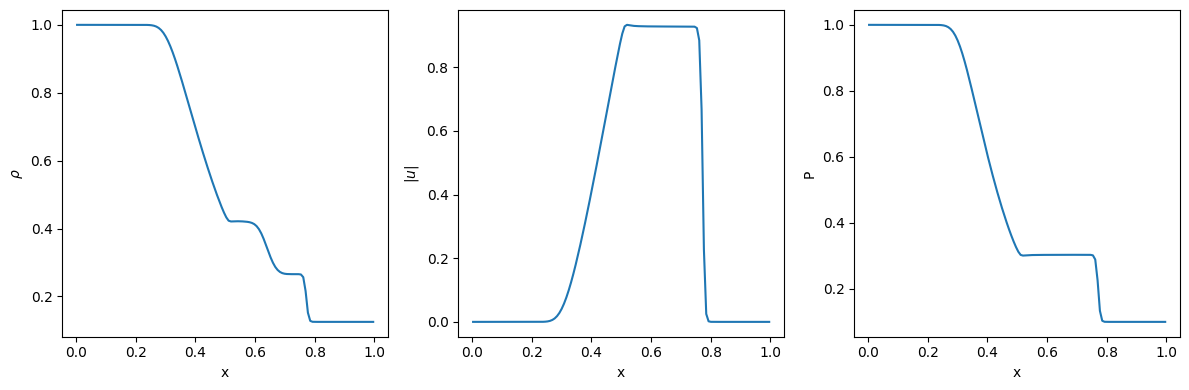

<Figure size 640x480 with 0 Axes>

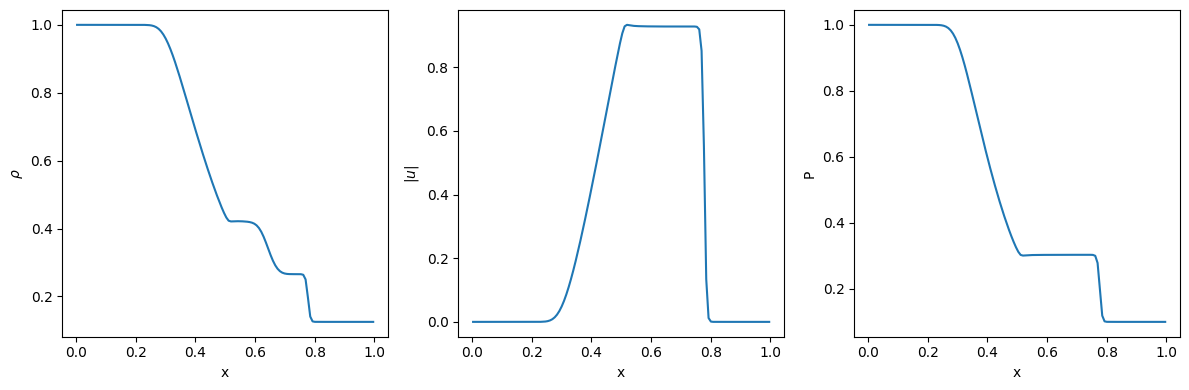

<Figure size 640x480 with 0 Axes>

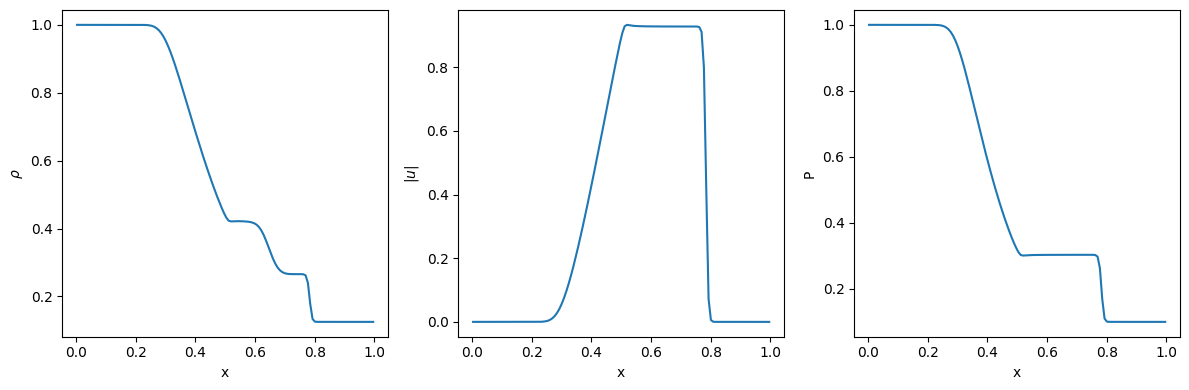

<Figure size 640x480 with 0 Axes>

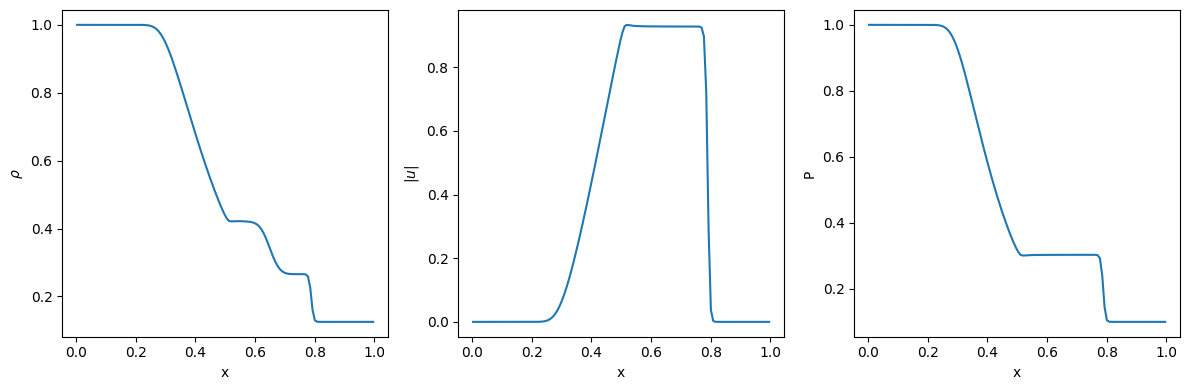

<Figure size 640x480 with 0 Axes>

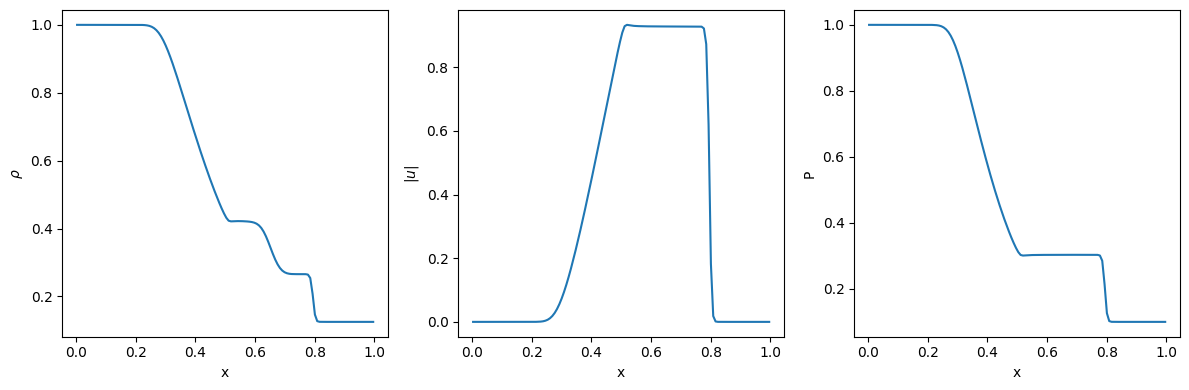

<Figure size 640x480 with 0 Axes>

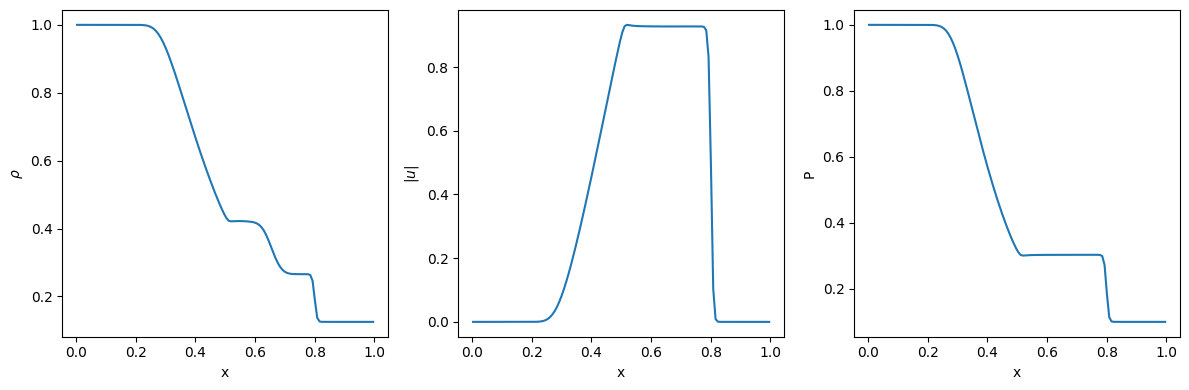

<Figure size 640x480 with 0 Axes>

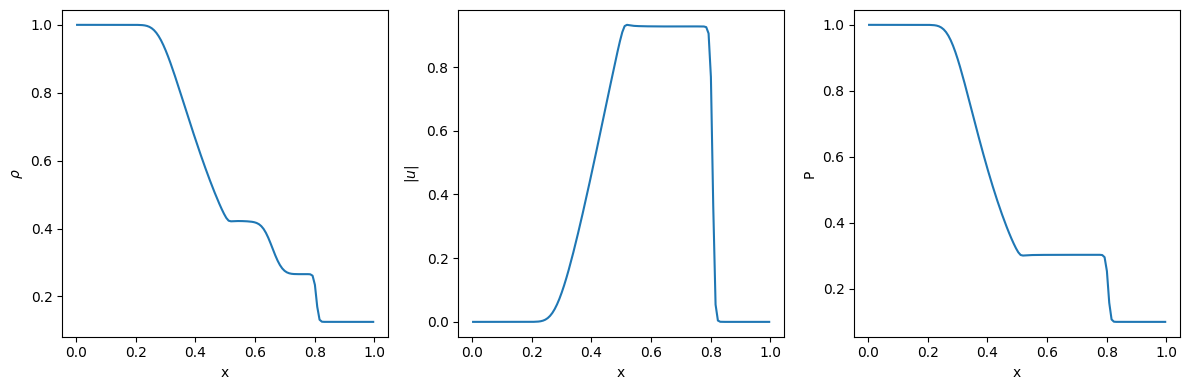

<Figure size 640x480 with 0 Axes>

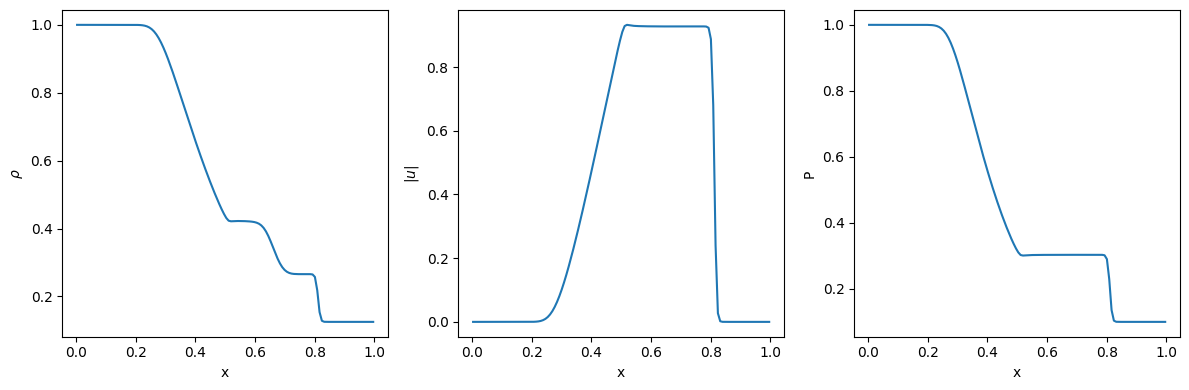

<Figure size 640x480 with 0 Axes>

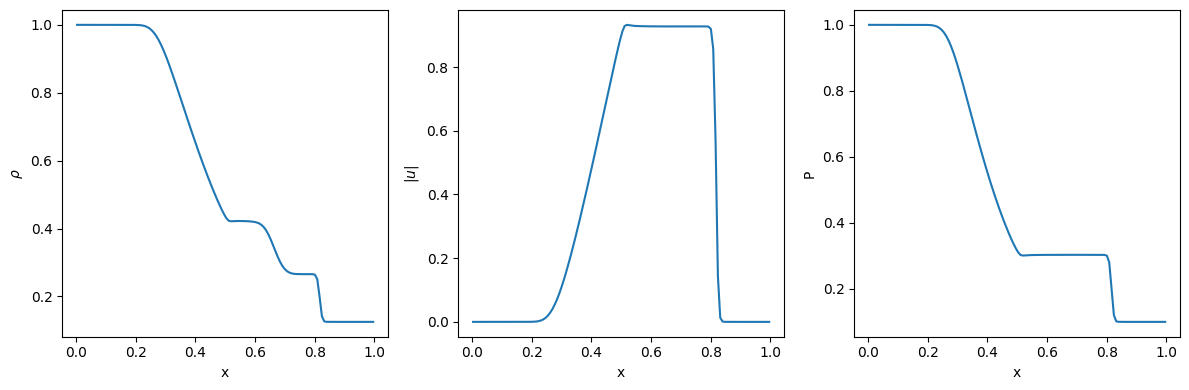

<Figure size 640x480 with 0 Axes>

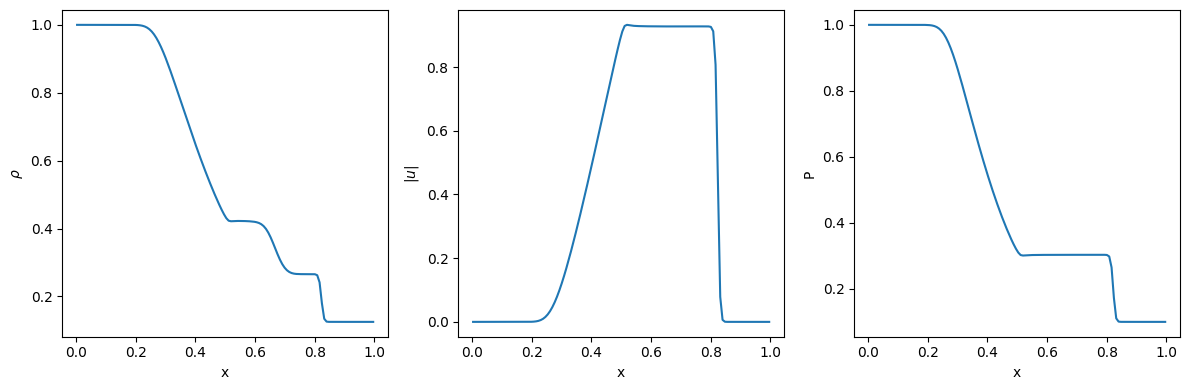

<Figure size 640x480 with 0 Axes>

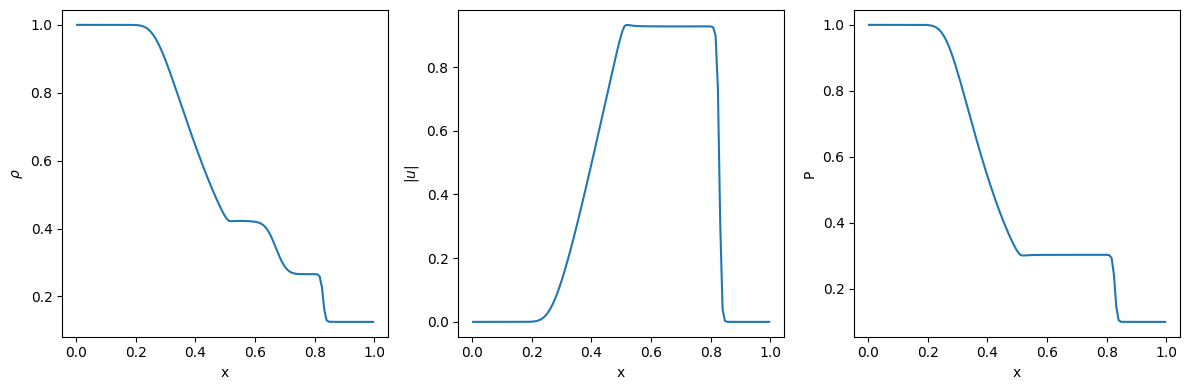

<Figure size 640x480 with 0 Axes>

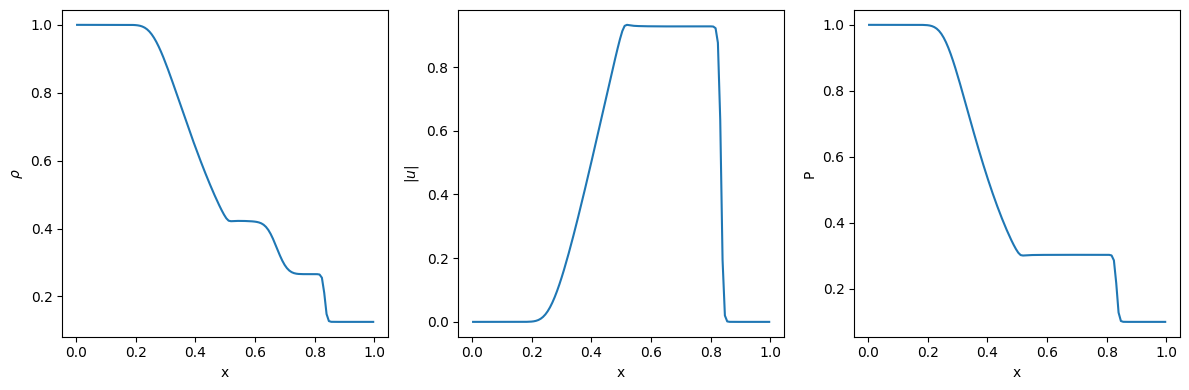

<Figure size 640x480 with 0 Axes>

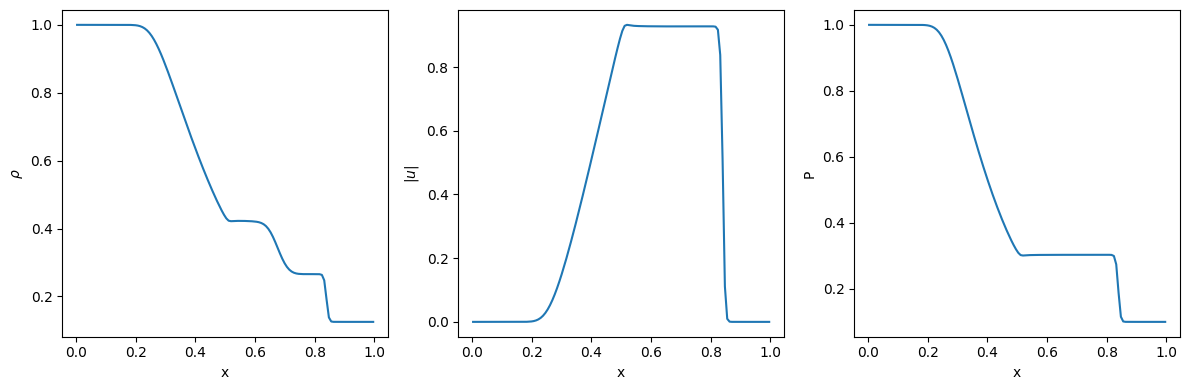

<Figure size 640x480 with 0 Axes>

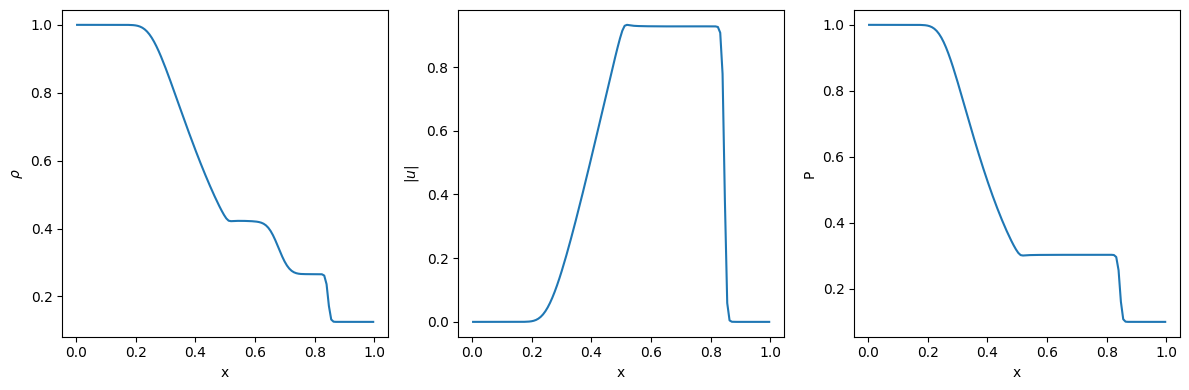

<Figure size 640x480 with 0 Axes>

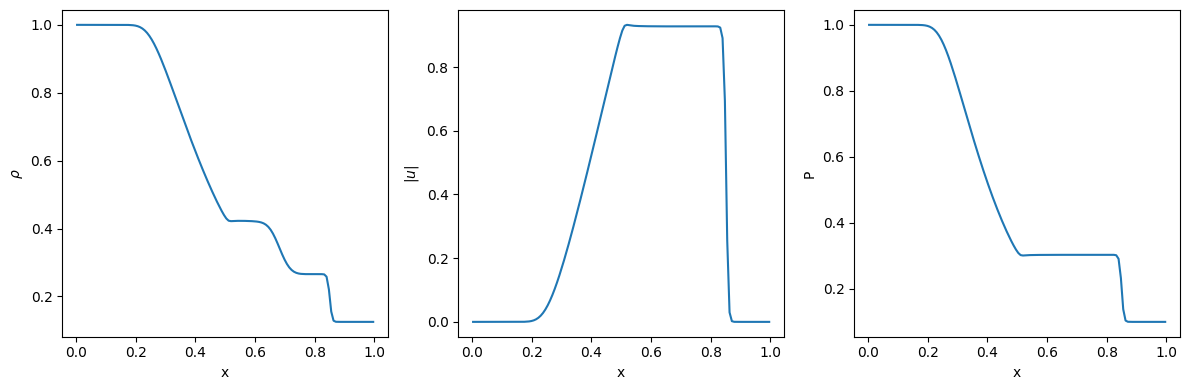

<Figure size 640x480 with 0 Axes>

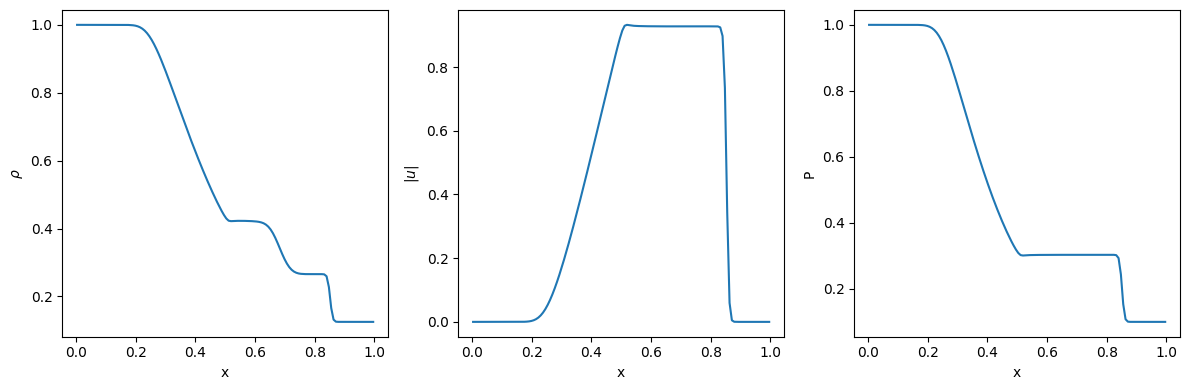

CPU times: user 13.4 s, sys: 10.3 s, total: 23.8 s
Wall time: 10 s


<Figure size 640x480 with 0 Axes>

In [9]:
%%time
# Courant–Friedrichs–Lewy (CFL) parameter
CFL = 0.9

t = t_start
while t < t_end:
    # get primitive variable
    rho = U[:,0]
    vel = U[:,1]/rho
    energy = U[:,2]
    pres = (gamma-1)*(energy - 0.5*rho*vel**2)
    
    # sound-speed
    cs = np.sqrt(gamma*pres/rho)
        
    # Courant–Friedrichs–Lewy (CFL) condition on time-step
    dt = CFL*dx/np.max(np.abs(vel)+cs)
    if t + dt > t_end:
        dt = t_end - t
    
    # compute fluxes at interfaces
    #F = hllc_flux(U) #TODO: this is not working (find the bug)
    F = roe_fluxes(U, gamma, eps_entropy=0.1)
               
    # update conserved variables
    for i in range(1, Nx-1):
        U[i] -= dt/dx*(F[i+1] - F[i])
    
    # plot current state
    axs = plot_state(x_grid=x, U=U)
    plt.show(), plt.clf()

    # update time-step
    t += dt

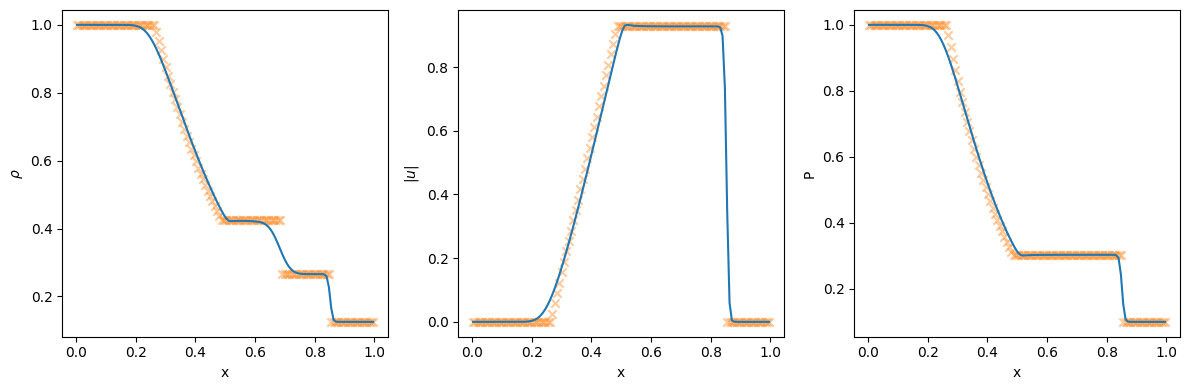

(None, None)

<Figure size 640x480 with 0 Axes>

In [10]:
sod = pd.read_csv('sod_exact.csv', index_col=0)
U_sod = np.array([sod['rho'].values, sod['rho'].values*sod['v'].values, sod['P'].values]).T

axs = plot_state(x_grid=x, U=U)
axs[0].scatter(sod['x'].values, sod['rho'].values, marker='x', alpha=0.4, color='tab:orange')
axs[1].scatter(sod['x'].values, sod['v'].values, marker='x', alpha=0.4, color='tab:orange')
axs[2].scatter(sod['x'].values, sod['P'].values, marker='x', alpha=0.4, color='tab:orange')

plt.show(), plt.clf()